Name: Aisshwarya Gurav

Roll No.: A_59

PRN: 2324000522

Assignment No. 8

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

test_dir = "/content/drive/MyDrive/DeepLearning/chest_xray/test"
train_dir = "/content/drive/MyDrive/DeepLearning/chest_xray/train"

In [ ]:
print(os.listdir(train_dir))
print(os.listdir(test_dir))

['NORMAL', 'PNEUMONIA']
['PNEUMONIA', 'NORMAL']


In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
print("Class labels:", train_generator.class_indices)

Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}


VGG16



In [ ]:
base=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
model=Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(2,'softmax')

])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

vgg16_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg16_base.layers:
    layer.trainable = False

In [ ]:
vgg16_model = Sequential()

vgg16_model.add(vgg16_base)
vgg16_model.add(Flatten())

vgg16_model.add(Dense(256, activation='relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.5))

vgg16_model.add(Dense(128, activation='relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.3))

vgg16_model.add(Dense(1, activation='sigmoid'))

In [ ]:
vgg16_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg16 = vgg16_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 497s 4s/step - accuracy: 0.9075 - loss: 0.2702 - val_accuracy: 0.9348 - val_loss: 0.1462
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 127s 971ms/step - accuracy: 0.9487 - loss: 0.1489 - val_accuracy: 0.9511 - val_loss: 0.1351
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 975ms/step - accuracy: 0.9573 - loss: 0.1236 - val_accuracy: 0.9281 - val_loss: 0.2449
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9571 - loss: 0.1187 - val_accuracy: 0.9693 - val_loss: 0.1027
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 129s 985ms/step - accuracy: 0.9629 - loss: 0.1049 - val_accuracy: 0.9712 - val_loss: 0.0770
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9679 - loss: 0.0949 - val_accuracy: 0.9626 - val_loss: 0.0857
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 992ms/step - accuracy: 0.9626 - loss: 0.1024 - val_accuracy: 0.9732 - val_loss: 0.0648
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 129s 982ms/step - accuracy: 0.9700 - loss: 0.

vgg19

In [ ]:
base=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
model=Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(2,'softmax')

])

In [ ]:

vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg19_base.layers:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
vgg19_model = Sequential()

vgg19_model.add(vgg19_base)
vgg19_model.add(Flatten())

vgg19_model.add(Dense(256, activation='relu'))
vgg19_model.add(BatchNormalization())
vgg19_model.add(Dropout(0.5))

vgg19_model.add(Dense(128, activation='relu'))
vgg19_model.add(BatchNormalization())
vgg19_model.add(Dropout(0.3))

vgg19_model.add(Dense(1, activation='sigmoid'))

In [ ]:
vgg19_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg19 = vgg19_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 702ms/step - accuracy: 0.8550 - loss: 0.4132 - val_accuracy: 0.8437 - val_loss: 0.5782
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 679ms/step - accuracy: 0.9416 - loss: 0.1906 - val_accuracy: 0.6903 - val_loss: 1.0583
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 679ms/step - accuracy: 0.9423 - loss: 0.1639 - val_accuracy: 0.9444 - val_loss: 0.1785
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 677ms/step - accuracy: 0.9525 - loss: 0.1423 - val_accuracy: 0.9597 - val_loss: 0.1058
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 683ms/step - accuracy: 0.9545 - loss: 0.1296 - val_accuracy: 0.9406 - val_loss: 0.1760
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 672ms/step - accuracy: 0.9625 - loss: 0.1094 - val_accuracy: 0.9569 - val_loss: 0.1298
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 673ms/step - accuracy: 0.9571 - loss: 0.1096 - val_accuracy: 0.9377 - val_loss: 0.1564


resnet50

In [ ]:
base=ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))
model=Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(2,'softmax')

])

In [ ]:

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in resnet_base.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
resnet_model = Sequential()

resnet_model.add(resnet_base)
resnet_model.add(Flatten())

resnet_model.add(Dense(256, activation='relu'))
resnet_model.add(BatchNormalization())
resnet_model.add(Dropout(0.5))

resnet_model.add(Dense(128, activation='relu'))
resnet_model.add(BatchNormalization())
resnet_model.add(Dropout(0.3))

resnet_model.add(Dense(1, activation='sigmoid'))

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 759ms/step - accuracy: 0.7802 - loss: 0.5100 - val_accuracy: 0.8821 - val_loss: 0.2549
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 672ms/step - accuracy: 0.9000 - loss: 0.2724 - val_accuracy: 0.9060 - val_loss: 0.2422
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 661ms/step - accuracy: 0.8888 - loss: 0.2682 - val_accuracy: 0.9214 - val_loss: 0.1907
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 667ms/step - accuracy: 0.9121 - loss: 0.2194 - val_accuracy: 0.7517 - val_loss: 0.9183
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 661ms/step - accuracy: 0.9233 - loss: 0.1974 - val_accuracy: 0.7430 - val_loss: 1.6569
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 661ms/step - accuracy: 0.9250 - loss: 0.2145 - val_accuracy: 0.8169 - val_loss: 0.4302


In [ ]:

vgg16_loss, vgg16_acc = vgg16_model.evaluate(test_generator)
vgg19_loss, vgg19_acc = vgg19_model.evaluate(test_generator)
resnet_loss, resnet_acc = resnet_model.evaluate(test_generator)

print("VGG16 Accuracy:", vgg16_acc)
print("VGG19 Accuracy:", vgg19_acc)
print("ResNet50 Accuracy:", resnet_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - accuracy: 0.8803 - loss: 0.3726
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.8904 - loss: 0.3088
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 372ms/step - accuracy: 0.6736 - loss: 0.8162
VGG16 Accuracy: 0.9166666865348816
VGG19 Accuracy: 0.9070512652397156
ResNet50 Accuracy: 0.817307710647583


In [ ]:


import numpy as np


true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Class Labels:", class_labels)

Class Labels: ['NORMAL', 'PNEUMONIA']


In [ ]:
vgg16_predictions = vgg16_model.predict(test_generator)

vgg16_predicted_classes = (vgg16_predictions > 0.5).astype("int32").flatten()

print("VGG16 Predicted Classes:")
print(vgg16_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step
VGG16 Predicted Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
vgg19_predictions = vgg19_model.predict(test_generator)

vgg19_predicted_classes = (vgg19_predictions > 0.5).astype("int32").flatten()

print("VGG19 Predicted Classes:")
print(vgg19_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step
VGG19 Predicted Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
resnet_predictions = resnet_model.predict(test_generator)

resnet_predicted_classes = (resnet_predictions > 0.5).astype("int32").flatten()

print("ResNet50 Predicted Classes:")
print(resnet_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step
ResNet50 Predicted Classes:
[0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


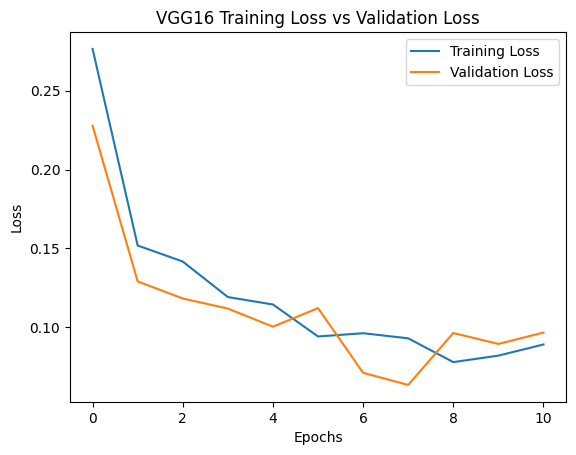

In [ ]:
plt.plot(history_vgg16.history['loss'], label='Training Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')

plt.title("VGG16 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

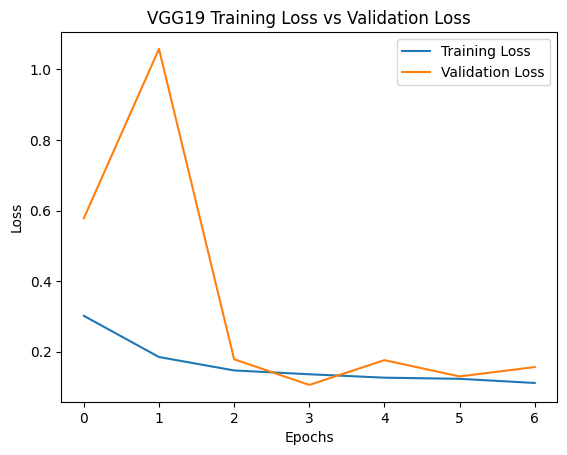

In [ ]:
plt.plot(history_vgg19.history['loss'], label='Training Loss')
plt.plot(history_vgg19.history['val_loss'], label='Validation Loss')

plt.title("VGG19 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

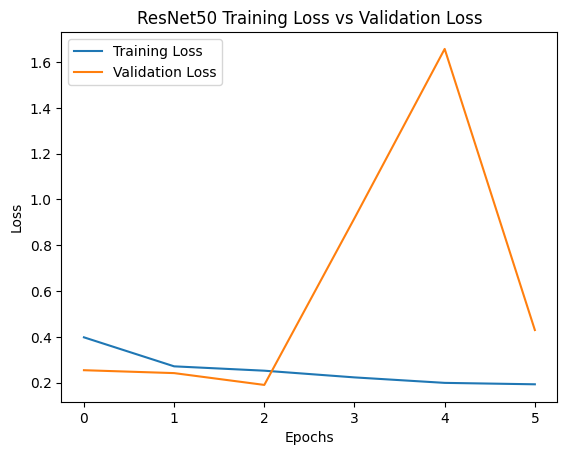

In [ ]:
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')

plt.title("ResNet50 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

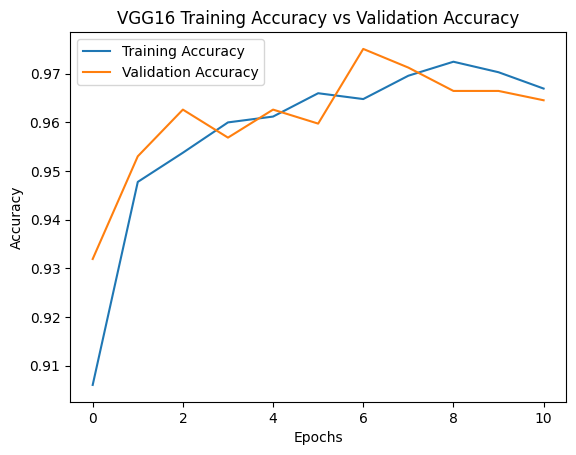

In [ ]:
plt.plot(history_vgg16.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

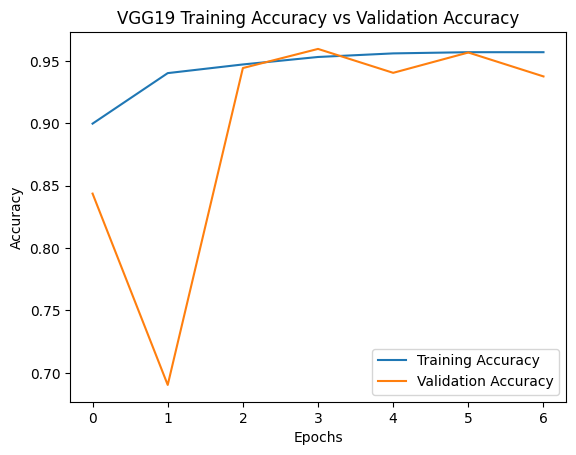

In [ ]:
plt.plot(history_vgg19.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG19 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

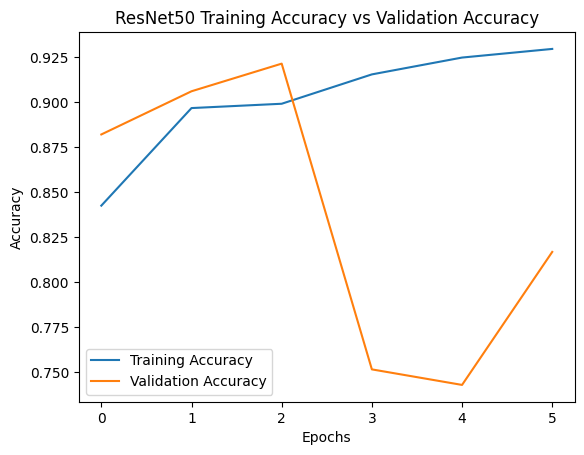

In [ ]:
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')

plt.title("ResNet50 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

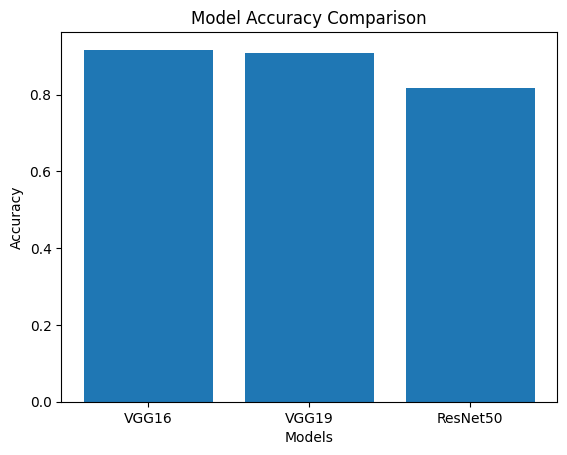

In [ ]:
models = ['VGG16', 'VGG19', 'ResNet50']
accuracies = [vgg16_acc, vgg19_acc, resnet_acc]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: PNEUMONIA DETECTED


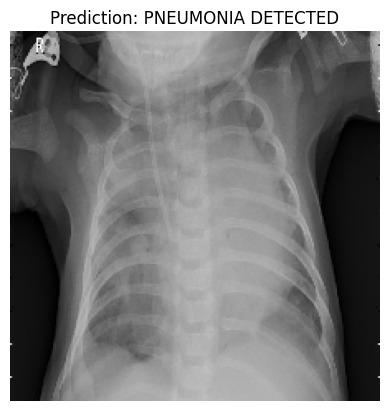

In [ ]:
img_path = "/content/drive/MyDrive/DeepLearning/chest_xray/test/PNEUMONIA/person100_bacteria_478.jpeg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Predict using VGG16
prediction = vgg16_model.predict(img_array)

# Output Result
if prediction[0][0] > 0.5:
    result = "PNEUMONIA DETECTED"
else:
    result = "NORMAL"

print("Prediction:", result)

# Show Image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + result)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: Normal


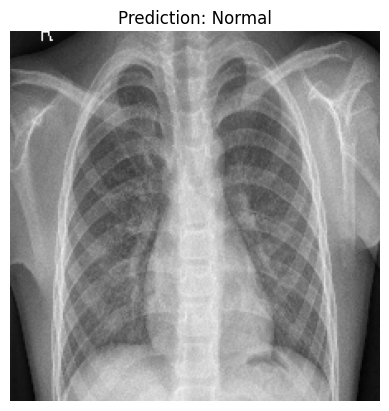

In [ ]:
img_path = "/content/drive/MyDrive/DeepLearning/chest_xray/test/NORMAL/IM-0003-0001.jpeg"

img = image.load_img(img_path, target_size=(224, 224))


img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


prediction = vgg16_model.predict(img_array)


if prediction[0][0] > 0.5:
    result = "Tumor (Cancerous)"
else:
    result = "Normal"

print("Prediction:", result)


plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + result)
plt.show()